In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

x, y = make_classification(n_samples=100, n_features=3, n_classes=2, n_informative=3, n_redundant=0, random_state=42, weights=[0.4, 0.6])


df = pd.DataFrame({"feature1": x[:, 0], "feature2": x[:, 1], "feature3": x[:, 2], "labels": y})

In [2]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=72)

In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### What does this probability represent?

- This probability represents what is the chance of label '0' and '1' classifies that instant. here we have selected probability of only label being '1'.

In [4]:
y_prob = model.predict_proba(x_test)[:, 1]
y_prob

array([0.88015713, 0.68031519, 0.56511694, 0.76237514, 0.94579645,
       0.34641049, 0.00719835, 0.0401002 , 0.76352518, 0.97845858,
       0.24373777, 0.6717522 , 0.81332896, 0.92210277, 0.05578816,
       0.02619895, 0.44509762, 0.93630143, 0.88255999, 0.94492012])

Default prediction at threshold 0.5

In [5]:
y_pred = model.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1])

Prediction at threshold 0.7

In [6]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.7, 0.5, 0.3, 0.2]

for threshold in thresholds:
    y_custom_pred = (y_prob >= threshold).astype(int)

    print(f"Threshold : {threshold}, Predictions : {y_custom_pred}, Precision score : {precision_score(y_test, y_custom_pred)}, Recall score :{recall_score(y_test, y_custom_pred)}")

Threshold : 0.7, Predictions : [1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 1 1 1], Precision score : 1.0, Recall score :0.9090909090909091
Threshold : 0.5, Predictions : [1 1 1 1 1 0 0 0 1 1 0 1 1 1 0 0 0 1 1 1], Precision score : 0.8461538461538461, Recall score :1.0
Threshold : 0.3, Predictions : [1 1 1 1 1 1 0 0 1 1 0 1 1 1 0 0 1 1 1 1], Precision score : 0.7333333333333333, Recall score :1.0
Threshold : 0.2, Predictions : [1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1], Precision score : 0.6875, Recall score :1.0


### What changed compared to default predictions ?

- Threshold decides which class to choose for which instant so by changing threshold every measure of metric and even prediction it self will change.

### Trade-off between precision and recall

- We cannot maintain both to be optimal and we need to prioritize one over other as you can see in cell 10's output as we keep decreasing threshold our recall becomes high while our precision keeps getting low. 
- There is no written rule to prioritize one over other it depends on what data you are working on for example if there is medical data and at the end someones life depends on you models prediction then you will want to have high recall than precision because false positive can be tolerated but false negative cannot be tolerated.

In [7]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

### ROC curve

- Roc curve helps us identify which threshold is better for classification model.

### What is TPR ?

- The true positive rate (TPR), or the proportion of all actual positives that were classified correctly as positives, is also known as recall. 
$$ TPR = \frac {TP} {TP\ +\ FN} $$

### What is FPR ? 

- The false positive rate (FPR) is the proportion of all actual negatives that were classified incorrectly as positives, also known as the probability of false alarm. It is mathematically defined as:
$$ FPR = \frac {FP} {FP\ +\ FN} $$

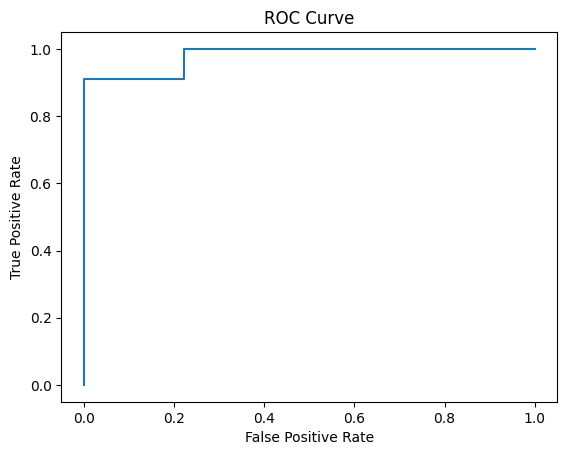

In [8]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## AUC Score

- Makes it easy to compare two ROC curves. Greater AUC is better. We will choose the model which has higher AUC score then other.

### Why is AUC score threshold independent ?

- The AUC (Area Under the Curve) is considered threshold-independent because it evaluates a model's performance across all possible classification thresholds, rather than at a single fixed threshold